<a href="https://colab.research.google.com/github/AB0219/part-2-cnn-computer-vision/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import files
uploaded = files.upload()

Saving images.zip to images (1).zip


In [20]:
import zipfile, os, io

os.makedirs('images', exist_ok=True)
zipfile.ZipFile(io.BytesIO(uploaded['images (1).zip']), 'r').extractall('images')
print("Images extracted to 'images' directory.")

Images extracted to 'images' directory.


In [21]:
"""
Problem Type:
Image Classification

Reason:
Each image belongs to exactly one class:
- normal
- scratch
- dent
- stain

The model predicts a single label for each image.
No bounding boxes or segmentation masks are provided.
"""

print("Problem Type: Image Classification")

Problem Type: Image Classification


Classes: ['normal', 'stain', 'dent', 'scratch']

Number of Images Per Class:
normal: 120
stain: 120
dent: 120
scratch: 120


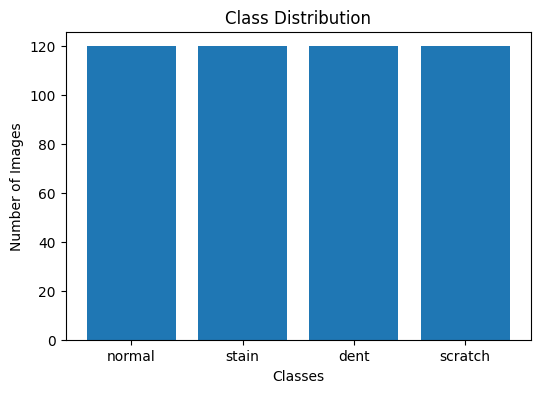

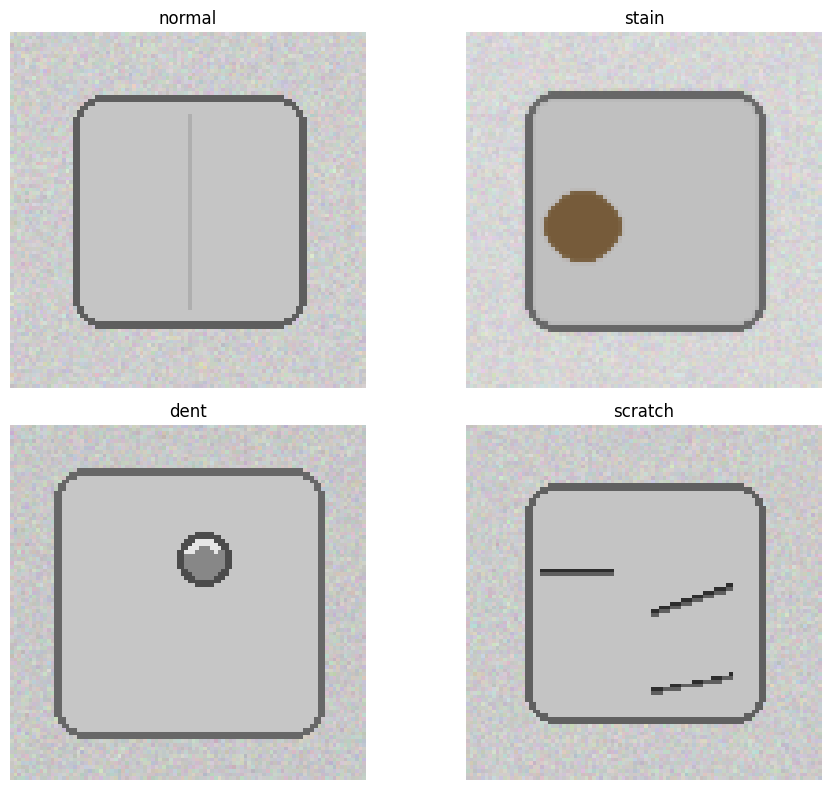


Image Dimensions:
normal: (96, 96, 3)
stain: (96, 96, 3)
dent: (96, 96, 3)
scratch: (96, 96, 3)


In [22]:
import os
import cv2
import matplotlib.pyplot as plt
from collections import Counter

base_extracted_dir = "images"
actual_dataset_dir = os.path.join(base_extracted_dir, "images")

if not os.path.isdir(actual_dataset_dir) or not os.listdir(actual_dataset_dir):
    dataset_path = base_extracted_dir
else:
    dataset_path = actual_dataset_dir

classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d)) and not d.startswith('.')] # Added .startswith('.') filter here

print("Classes:", classes)

print("\nNumber of Images Per Class:")

image_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    valid_image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
    count = len(valid_image_files)
    image_counts[cls] = count
    print(f"{cls}: {count}")

plt.figure(figsize=(6,4))
plt.bar(image_counts.keys(), image_counts.values())
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.savefig("class_distribution.png")
plt.show()

plt.figure(figsize=(10,8))

for i, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)
    valid_image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

    if not valid_image_files:
        print(f"Warning: No valid image files found in class '{cls}' at '{class_path}'. Skipping sample display for this class.")
        continue

    img_name = valid_image_files[0]
    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not read image {img_path}. Skipping.")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.savefig("sample_images.png")
plt.show()

print("\nImage Dimensions:")

for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    valid_image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

    if not valid_image_files:
        print(f"Warning: No valid image files found in class '{cls}' at '{class_path}'. Skipping dimension check for this class.")
        continue

    img_name = valid_image_files[0]
    img_path = os.path.join(class_path, img_name)

    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not read image {img_path}. Skipping dimension check.")
        continue

    print(f"{cls}: {img.shape}")


In [23]:
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 128

X = []
y = []

label_dict = {
    "normal": 0,
    "scratch": 1,
    "dent": 2,
    "stain": 3
}

for cls in classes:

    class_path = os.path.join(dataset_path, cls)

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        img = cv2.imread(img_path)

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        img = img / 255.0

        X.append(img)
        y.append(label_dict[cls])

X = np.array(X)
y = np.array(y)

y = to_categorical(y, num_classes=4)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

Training Data Shape: (384, 128, 128, 3)
Testing Data Shape: (96, 128, 128, 3)


In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),

    MaxPooling2D(2,2),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(4, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.2708 - loss: 1.4356 - val_accuracy: 0.2500 - val_loss: 1.3878
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.2760 - loss: 1.3909 - val_accuracy: 0.2500 - val_loss: 1.3839
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.2917 - loss: 1.3788 - val_accuracy: 0.2917 - val_loss: 1.3443
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.4089 - loss: 1.2640 - val_accuracy: 0.5417 - val_loss: 1.1434
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.5573 - loss: 0.9936 - val_accuracy: 0.6562 - val_loss: 0.9160
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.6536 - loss: 0.8378 - val_accuracy: 0.6667 - val_loss: 0.7270
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.7109 - loss: 0.6322 - val_accuracy: 0.8021 - val_loss: 0.6628
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.7656 - loss: 0.6104 - val_accuracy: 0.8750 - val_loss:

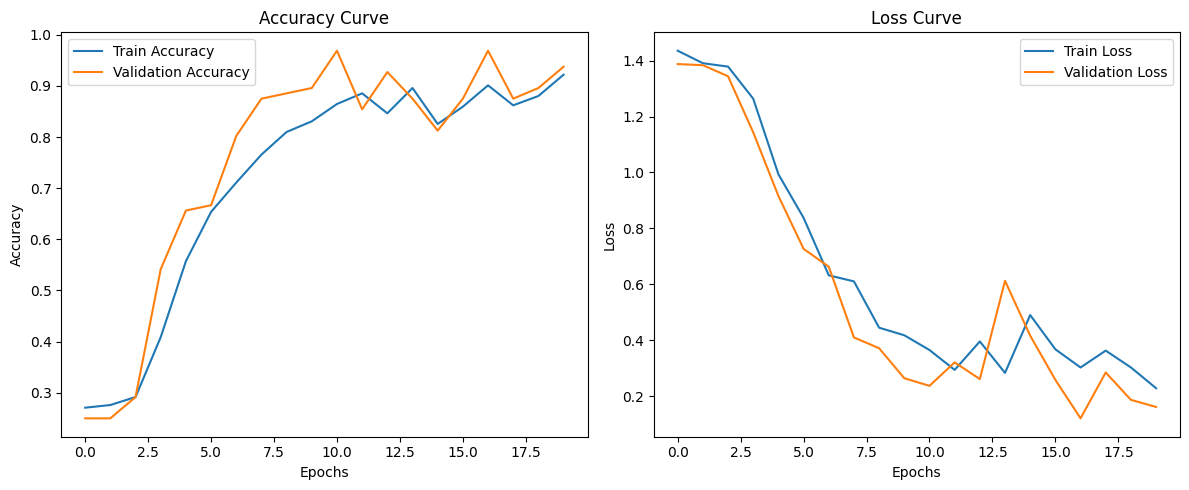

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 250ms/step - accuracy: 0.9375 - loss: 0.1611

Test Accuracy: 0.9375
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 241ms/step

Classification Report:

              precision    recall  f1-score   support

      normal       0.92      1.00      0.96        24
     scratch       0.88      0.92      0.90        24
        dent       0.95      0.88      0.91        24
       stain       1.00      0.96      0.98        24

    accuracy                           0.94        96
   macro avg       0.94      0.94      0.94        96
weighted avg       0.94      0.94      0.94        96



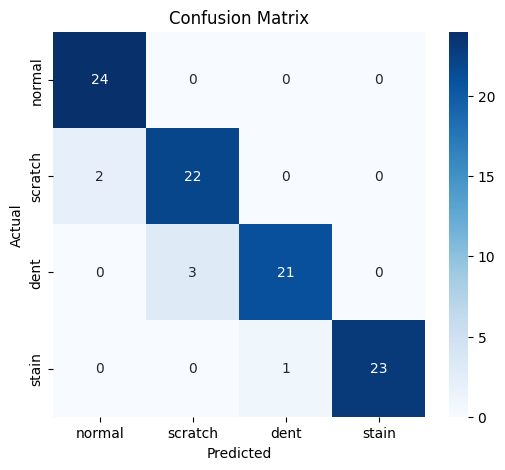

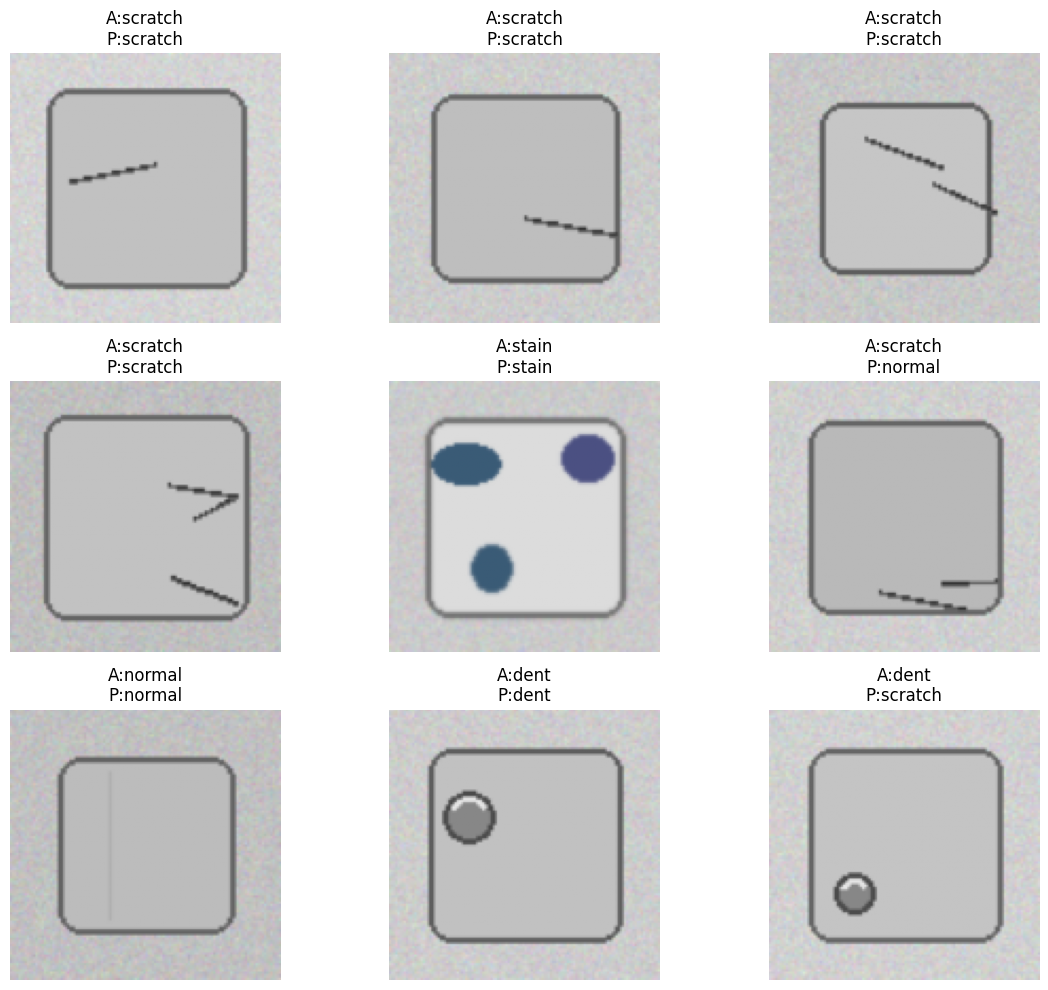

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=20,
    validation_data=(X_test, y_test)
)



plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()

plt.savefig("accuracy_loss_curves.png")

plt.show()


test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", test_accuracy)



y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)



print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred_classes,
    target_names=label_dict.keys()
))


cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_dict.keys(),
    yticklabels=label_dict.keys()
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")

plt.show()


class_names = list(label_dict.keys())

plt.figure(figsize=(12,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_test[i])

    actual = class_names[y_true[i]]
    predicted = class_names[y_pred_classes[i]]

    plt.title(f"A:{actual}\nP:{predicted}")

    plt.axis("off")

plt.tight_layout()

plt.savefig("prediction_outputs.png")

plt.show()

In [26]:
"""
1. What is Convolution?

Convolution uses filters/kernels to scan images
and extract important features such as:
- edges
- textures
- shapes

2. Why is Pooling Used?

Pooling reduces image size while keeping
important information.

Benefits:
- reduces computation
- prevents overfitting
- improves efficiency

3. Why is ReLU Used?

ReLU introduces non-linearity.

Formula:
f(x) = max(0, x)

Benefits:
- faster training
- avoids vanishing gradient problem

4. Why CNNs Are Better Than Feed-Forward Networks?

CNNs:
- preserve spatial relationships
- automatically extract features
- require fewer parameters
- work efficiently on images
"""

'\n1. What is Convolution?\n\nConvolution uses filters/kernels to scan images\nand extract important features such as:\n- edges\n- textures\n- shapes\n\n2. Why is Pooling Used?\n\nPooling reduces image size while keeping\nimportant information.\n\nBenefits:\n- reduces computation\n- prevents overfitting\n- improves efficiency\n\n3. Why is ReLU Used?\n\nReLU introduces non-linearity.\n\nFormula:\nf(x) = max(0, x)\n\nBenefits:\n- faster training\n- avoids vanishing gradient problem\n\n4. Why CNNs Are Better Than Feed-Forward Networks?\n\nCNNs:\n- preserve spatial relationships\n- automatically extract features\n- require fewer parameters\n- work efficiently on images\n'

In [27]:
"""
Manufacturing Quality Inspection

This CNN-based defect detection system can be
used in manufacturing industries to automatically
identify defective products.

Applications:
- automobile inspection
- metal surface inspection
- packaging quality control
- electronics manufacturing

Benefits:
- reduces manual inspection
- improves accuracy
- increases production speed
- lowers operational cost

Workflow:
1. Capture product image
2. CNN analyzes image
3. Detect defect type
4. Remove defective product
"""

'\nManufacturing Quality Inspection\n\nThis CNN-based defect detection system can be\nused in manufacturing industries to automatically\nidentify defective products.\n\nApplications:\n- automobile inspection\n- metal surface inspection\n- packaging quality control\n- electronics manufacturing\n\nBenefits:\n- reduces manual inspection\n- improves accuracy\n- increases production speed\n- lowers operational cost\n\nWorkflow:\n1. Capture product image\n2. CNN analyzes image\n3. Detect defect type\n4. Remove defective product\n'